# Comprehensive Book Recommendation System
### Leveraging Collaborative Filtering and Unsupervised Machine Learning (kNN)

**Project Overview:** This project implements an end-to-end Machine Learning pipeline to build a Personalized Book Recommendation Engine utilizing the Book-Crossing dataset. The system filters out algorithmic noise, addresses data sparsity challenges, and implements a User-Item memory-based Collaborative Filtering approach using Cosine Similarity.

**Key Technical Achievements:**
* **Optimized Pipeline:** Streamlined data extraction and transformation across three relational datasets representing over 1 million records.
* **Feature Engineering & Filtering:** Implemented popularity and geographic thresholds to scale down dense interactions, significantly reducing computational overhead.
* **Spatial Modeling:** Handled data sparsity using Compressed Sparse Row (CSR) matrices and built a Nearest Neighbors inference engine with a custom Cosine Distance metric.

# 1. import library and data

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
import pickle
import warnings

# Configure environment settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc("font", size=12)

# Define dataset schemas and ingest records with standard comma-delimiter parsing
print("[INFO] Initializing dataset ingestion pipeline...")

books = pd.read_csv("Books.csv", sep=",", encoding="latin-1", engine="python", on_bad_lines="skip")
users = pd.read_csv("Users.csv", sep=",", encoding="latin-1", engine="python", on_bad_lines="skip")
ratings = pd.read_csv("Ratings.csv", sep=",", encoding="latin-1", engine="python", on_bad_lines="skip")

# Standardize features using camelCase formatting for clean structural access
books.rename(columns={
    'Book-Title': 'bookTitle', 'Book-Author': 'bookAuthor',
    'Year-Of-Publication': 'yearOfPublication', 'Publisher': 'publisher',
    'Image-URL-S': 'imageUrlS', 'Image-URL-M': 'imageUrlM', 'Image-URL-L': 'imageUrlL'
}, inplace=True)

users.rename(columns={'User-ID': 'userID', 'Location': 'Location', 'Age': 'Age'}, inplace=True)
ratings.rename(columns={'User-ID': 'userID', 'Book-Rating': 'bookRating'}, inplace=True)

print(f"-> Ingested {books.shape[0]:,} Books, {users.shape[0]:,} Users, and {ratings.shape[0]:,} Ratings rows successfully.")

[INFO] Initializing dataset ingestion pipeline...
-> Ingested 271,360 Books, 278,858 Users, and 1,149,780 Ratings rows successfully.


## 1. Exploratory Data Analysis (EDA)
To understand data distribution, explicit interactions, and demographics, we visualize the target fields (`bookRating` and `Age`). This informs our thresholding parameters for filtering out skewed observations.

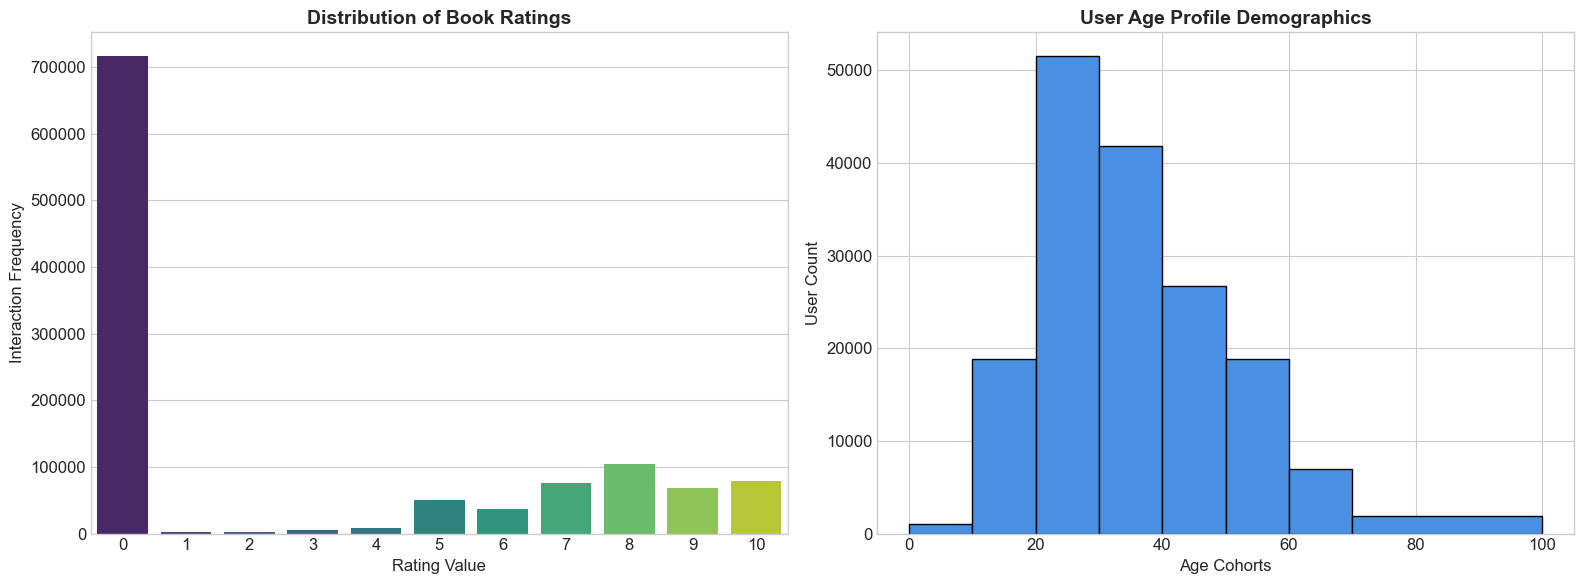

In [37]:
# Create multi-panel visualizations for distribution analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Explicit vs Implicit Rating Distributions
sns.countplot(data=ratings, x='bookRating', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Book Ratings', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating Value')
axes[0].set_ylabel('Interaction Frequency')

# Subplot 2: User Demographics
axes[1].hist(users['Age'].dropna(), bins=[0, 10, 20, 30, 40, 50, 60, 70, 100], color='#4a90e2', edgecolor='black')
axes[1].set_title('User Age Profile Demographics', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Cohorts')
axes[1].set_ylabel('User Count')

plt.tight_layout()
plt.show()

## 2. Advanced Feature Engineering & Dimensionality Reduction
Collaborative filtering models are highly sensitive to **Cold Start** problems and high-dimensional sparsity. 
* **Book Isolation Threshold:** We filter out obscure titles by keeping only books that have received at least **100 individual ratings**.
* **Geographic Stratification:** We slice data for regional affinity mapping, scoping our sample space to users located across the USA and Canada to ensure uniform cultural preference patterns.

In [38]:
# Generate explicit cumulative ratings per title
print("[INFO] Computing aggregate interaction frequencies per book...")
combine_book_rating = ratings.merge(books, on='ISBN', how='inner').dropna(axis=0, subset=['bookTitle'])

book_ratingCount = (combine_book_rating.
                    groupby('bookTitle')['bookRating'].
                    count().
                    reset_index().
                    rename(columns={'bookRating': 'totalRatingCount'}))

# Inject statistical counts back into interaction arrays
rating_popular_book = combine_book_rating.merge(book_ratingCount, on='bookTitle', how='left')

# Enforce statistical minimum configuration parameters (Threshold >= 100)
popularity_threshold = 100
filtered_popular_books = rating_popular_book.query('totalRatingCount >= @popularity_threshold')

# Segment demographics to isolate targeted markets
demographic_merged = filtered_popular_books.merge(users, on='userID', how='left')
us_canada_user_rating = demographic_merged[demographic_merged['Location'].str.contains("usa|canada", case=False, na=False)]

# Drop unneeded features to maintain optimal RAM footprints
if 'Age' in us_canada_user_rating.columns:
    us_canada_user_rating = us_canada_user_rating.drop('Age', axis=1)

print(f"-> Shape post-filtering: {us_canada_user_rating.shape[0]:,} active user-item records remaining.")

[INFO] Computing aggregate interaction frequencies per book...
-> Shape post-filtering: 160,445 active user-item records remaining.


## 3. High-Dimensional Matrix Formulation & Unsupervised Model Fitting
We reshape our unstructured tabular matrix into a formal mathematical coordinates grid ($M \times N$ User-Item Interaction Grid). Because most cells are empty ($0$), we store the array inside a **Compressed Sparse Row (CSR) Matrix** to save memory and scale matrix computations. 

We apply the **k-Nearest Neighbors (kNN)** algorithm using a **Cosine Similarity distance metric** to discover latent cluster groups of comparable reading profiles.

In [39]:
# Remove identical multi-edition tracking inputs to shield pivot alignment from shape collisions
final_clean_df = us_canada_user_rating.drop_duplicates(['userID', 'bookTitle'])

# Construct the User-Item interaction matrix
print("[INFO] Pivoting dataframe to high-dimensional User-Item interaction space...")
interaction_pivot = final_clean_df.pivot(index='bookTitle', columns='userID', values='bookRating').fillna(0)

# Compress coordinates representation for scalable execution
sparse_interaction_matrix = csr_matrix(interaction_pivot.values)

# Initialize and fit the Unsupervised Nearest Neighbors Engine
print("[INFO] Training Unsupervised kNN Engine using Cosine Similarity...")
model_knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=6)
model_knn.fit(sparse_interaction_matrix)

print("-> Model training complete.")

[INFO] Pivoting dataframe to high-dimensional User-Item interaction space...
[INFO] Training Unsupervised kNN Engine using Cosine Similarity...
-> Model training complete.


## 4. Inference Engine Evaluation Showcase
Using our spatial neighborhood paths, we query a randomized item identifier vector to calculate and isolate the five closest relative book entities based on minimal angular cosine separation.

In [40]:
# Extract target vector observation sample profile
query_index = np.random.choice(interaction_pivot.shape[0])
target_book = interaction_pivot.index[query_index]

# Perform directional lookup query
distances, indices = model_knn.kneighbors(
    interaction_pivot.iloc[query_index, :].values.reshape(1, -1), 
    n_neighbors=6
)

print(f"Target Query Profile: '{target_book}'\n" + "="*50)
for i in range(1, len(distances.flatten())):
    neighbor_book = interaction_pivot.index[indices.flatten()[i]]
    distance_score = distances.flatten()[i]
    print(f"Rank {i} Recommendation: '{neighbor_book}' | Cosine Distance Score: {distance_score:.4f}")

Target Query Profile: 'Small Town Girl'
Rank 1 Recommendation: 'That Camden Summer' | Cosine Distance Score: 0.7081
Rank 2 Recommendation: 'The Gift' | Cosine Distance Score: 0.8404
Rank 3 Recommendation: 'Night Whispers' | Cosine Distance Score: 0.8457
Rank 4 Recommendation: 'Key of Knowledge (Key Trilogy (Paperback))' | Cosine Distance Score: 0.8787
Rank 5 Recommendation: 'Daddy' | Cosine Distance Score: 0.8814


## 5. Model Serialization for Production Deployment
To prepare this system for scalable deployment inside a web application container (e.g., Streamlit, Flask, or FastAPI), we serialize both the mathematical similarity weights and data frames into portable binary structures.

In [41]:
print("[INFO] Exporting binaries for application server deployment...")

with open('book_knn_model.pkl', 'wb') as model_file:
    pickle.dump(model_knn, model_file)

with open('book_pivot_matrix.pkl', 'wb') as matrix_file:
    pickle.dump(interaction_pivot, matrix_file)

print("-> Model ('book_knn_model.pkl') and Interaction Matrix Matrix ('book_pivot_matrix.pkl') successfully saved.")

[INFO] Exporting binaries for application server deployment...
-> Model ('book_knn_model.pkl') and Interaction Matrix Matrix ('book_pivot_matrix.pkl') successfully saved.
